In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

# ※ Quiz:경주여행과 전주여행에 대해 최빈단어시각화와 유사도분석
- (1) naver open API를 활용하여 블로그에 "경주여행", "전주여행"을 각각 500건씩 검색하여 백업
       (data/quiz/naver.csv)
    * 파일 내용 : query, no, title, link, description, total_text(title + ' ' + description)
- (2) naver.csv에서 total_text를 품사태깅(naver_pos.csv)
    * 파일 내용 : query, no, token, pos
- (3) 명사만 추출(naver_pos_nouns.csv)
    * query, token, pos
- (4) 빈도분석 백업(naver_pos_nouns_count.csv)
    * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도 시각화(워드클라우드, Text.plot)
    * 이미지 저장
- (6) 단어간 거리 분석(Word2Vec)

## 1. 네이버 open API 활용하여 검색 추출
- query, no, title, link, description, total_text(title + ' ' + description)

In [3]:
# .env 가져오기
from dotenv import load_dotenv
import os
load_dotenv()

True

In [4]:
# 네이버 개발자 센터에 있는 소스를 가져오기
# 네이버 검색 API 예제 - 블로그 검색
import os
import sys
import urllib.request
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog.json?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:200])
   # items = json.loads(response_body.decode('utf-8'))
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 12:52:30 +0900",
	"total":2737577,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"3월의 <b>경주여행<\/b>.",
			"link":"https:\/\/lje77777.tistory.com\/7132",
			"


In [5]:
# 문자->dict
import json 
from html import unescape # description에 있는 &lt;(특수문자)를 <로 변경
import requests
import pandas as pd
import re  # 특수문자 제거 @@ _._ 

In [6]:
query = "경주 여행"
start = 1
# url = f"https://openapi.naver.com/v1/search/blog.json?query={query}&display=100&start={start}"
url = "https://openapi.naver.com/v1/search/blog.json"
params = {
    'query':query,
    'display':100,
    'start':start
}
headers = {
    "X-Naver-Client-Id":client_id,
    "X-Naver-Client-Secret":client_secret
}
response = requests.get(url, headers=headers, params=params)
# 문자 -> dict
items = json.loads(response.text)['items']
items = response.json()['items']
items[4]

{'title': '경북 <b>경주여행</b>/불국사-단아함과 정숙함이 묻어나는 겹벚꽃(왕벚꽃)....',
 'link': 'https://skdywjd25.tistory.com/5973',
 'description': '벚꽃이 다 지고나면 피는 겹벗꽃 봄 <b>여행</b>을 즐기는 고수라면 서둘러 <b>경주</b>행 티켓을 예약하자. 또다시 <b>경주</b>가 들썩이고 있다.다 <b>경주</b>지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다. 불국사 입구에... ',
 'bloggername': '산행과여행 사진으로 말한다',
 'bloggerlink': 'https://skdywjd25.tistory.com/',
 'postdate': '20190425'}

In [7]:
# title과 description의 <b>없애기, html의 특수문자없애기, 일반특수 없애기
item = items[4]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
title = unescape(title)
title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description)
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
link = item['link']
totaltext = title + ' ' + description
print(totaltext)
print(link)

경북  경주여행  불국사 단아함과 정숙함이 묻어나는 겹벚꽃 왕벚꽃      벚꽃이 다 지고나면 피는 겹벗꽃 봄  여행 을 즐기는 고수라면 서둘러  경주 행 티켓을 예약하자  또다시  경주 가 들썩이고 있다 다  경주 지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다  불국사 입구에    
https://skdywjd25.tistory.com/5973


In [8]:
# re 정규표현식을 이용해서 특수문자 없애기
title = '[여행] ## & ktx 타고 짱 ㅋㅋ ㅠㅠ'
re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)

' 여행       ktx 타고 짱      '

In [9]:
# 네이버 API 정보 및 검색 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

queries = ['경주 여행', '전주 여행']
max_start = 5

In [10]:
def get_search_item_return(query, start):
    'query, no, title, link, description, total_text(title + ' ' + description)'
    import requests
    # import json
    from html import unescape # html 특수문자 제거(ex. &nbsp; 제거)
    import re # 일반 특수문자 제거(__.__제거)
    from dotenv import load_dotenv
    import os
    load_dotenv() # .env파일 읽어오기(환경변수 설정)
    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')
    url = "https://openapi.naver.com/v1/search/blog.json"
    params = {
        'query':query,
        'display':100,
        'start':start
    }
    headers = {
        "X-Naver-Client-Id":client_id,
        "X-Naver-Client-Secret":client_secret
    }
    response = requests.get(url, headers=headers, params=params)
    # 문자 -> dict
    # items = json.loads(response.text)['items']
    items = response.json()['items'] # 100개
    result = [] # items의 title, link, description등을 dict list로 append
    for i, item in enumerate(items):
        no = (start-1)*100 + i+1 # start가 1일때는 1,2,3.. start가 2일때는 101, 102,..
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        total_text = title + ' ' + description
      # print(query, no, title[:5], link, description[:5], total_text[:5])
        result.append({'query'       :query,
                       'no'          :no,
                       'title'       :title,
                       'link'        :link, 
                       'description' :description,
                       'total_text'  :total_text
                        })
    return result

In [11]:
import time
queries = ['경주 여행', '전주 여행']
max_start = 5
result_total = []
for query in queries:
    for start in range(1, max_start+1):
        print(f'{query} 읽어오는 중...{start}/{max_start}')
        result_total.extend(get_search_item_return(query, start))
        time.sleep(0.5)

경주 여행 읽어오는 중...1/5
경주 여행 읽어오는 중...2/5
경주 여행 읽어오는 중...3/5
경주 여행 읽어오는 중...4/5
경주 여행 읽어오는 중...5/5
전주 여행 읽어오는 중...1/5
전주 여행 읽어오는 중...2/5
전주 여행 읽어오는 중...3/5
전주 여행 읽어오는 중...4/5
전주 여행 읽어오는 중...5/5


In [12]:
import pandas as pd
df = pd.DataFrame(result_total)
print(df.shape)
df.loc[498:501]

(1000, 6)


,query,no,title,link,description,total_text
498,경주 여행,499,가을 경주 여행,https://lje77777.tistory.com/7492,경주 도착 오늘은 작년 여름 경주여행 코스였던 서출지와 통일전 그리고 산림 ...,가을 경주 여행 경주 도착 오늘은 작년 여름 경주여행 코스였던 서출지와...
499,경주 여행,500,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행,https://blog.aladin.co.kr/787898106/12069804,일상이 고고학 나 혼자 경주 여행 개정증보판 일상이 고고학 시리즈 2 ...,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 일상이 고고학 ...
500,전주 여행,1,알라딘서재 전주 당일 여행,https://blog.aladin.co.kr/melldy/5785245,전주여행 20120707 버스를 타고 마음이 두근두근두근 음악도 들으면서 핸...,알라딘서재 전주 당일 여행 전주여행 20120707 버스를 타고 마음이 ...
501,전주 여행,2,전주여행 전주 한옥마을 아카 갤러리카페 Jeonju Hanok Vill...,https://desert.tistory.com/6371,전주여행 전주 한옥마을 아카 갤러리카페 전주 한옥마을 Jeonju H...,전주여행 전주 한옥마을 아카 갤러리카페 Jeonju Hanok Vill...


In [13]:
df.to_csv('data/quiz_naver.csv', encoding='cp949', index=False)

## 2. 품사 태깅 백업
- query, no, token, pos -> quiz_naver_pos백업

In [14]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')
df.head(1)

,query,no,title,link,description,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사,https://green54.tistory.com/1244,경주여행 때 방문했던 곳들을 다시 한번 남겨보려함 경주여행 경주 밤...,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...


In [15]:
df_list = df[['query', 'no', 'total_text']].values.tolist()
df_list[::500], len(df_list)

([['경주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 '],
  ['전주 여행',
   1,
   ' 알라딘서재  전주  당일 여행   전주여행  20120707 버스를 타고 마음이 두근두근두근  음악도 들으면서  핸드폰도 바꾸고 버스에서 내리니 날씨가 너무 화창했어욤    버스가 안와서 한참을 기다린  버스타고 전동성당으로 향했어요  말로만듣던    ']],
 1000)

In [16]:
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
postagged_list = [] # 품사태깅한 dict list (query, no, token, pos)
stopwords = ['전주', '여행', '경주']
for i, row in enumerate(df_list):
    if i%200==0:
        print(f'총 1000번중 현재 {i}번째 품사태깅중')
    query = row[0]
    no    = row[1]
    total_text = row[2]
    tagged_list = analyzer.pos(total_text)
    for token, tag in tagged_list:
        if token not in stopwords and len(token)>1: # 두 글자 이상의 stopword가 아닌 token
            postagged_list.append({'query' : query,
                                   'no'    : no, 
                                   'token' : token,
                                   'pos'   : tag})

총 1000번중 현재 0번째 품사태깅중
총 1000번중 현재 200번째 품사태깅중
총 1000번중 현재 400번째 품사태깅중
총 1000번중 현재 600번째 품사태깅중
총 1000번중 현재 800번째 품사태깅중


In [17]:
df_postagged = pd.DataFrame(postagged_list)
df_postagged.to_csv('data/quiz_naver_pos.csv', encoding='cp949', index=False)

## 3. 명사만 추출
- MeCab에서의 명사(NNG, NNP, NP)
- query, token, pos

In [18]:
df_postagged = pd.read_csv('data/quiz_naver_pos.csv', encoding='cp949')
select_pos = ['NNG', 'NNP', 'NP']
df_postagged.sample()

,query,no,token,pos
11835,경주 여행,466,세계,NNG


In [19]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(select_pos), ['query', 'token', 'pos']]
df_nouns.sample()

,query,token,pos
19579,전주 여행,케이,NNG


In [20]:
df_nouns.to_csv('data/quiz_naver_pos_noun.csv', encoding='cp949', index=False)

## 4. 빈도분석
- token, 경주빈도, 전주빈도, 빈도합, 경주비율, 전주비율

In [21]:
df_nouns.groupby(['query'], as_index=False)['pos'].count()

,query,pos
0,경주 여행,8025
1,전주 여행,8978


In [22]:
df_token_grp = df_nouns.groupby(['query', 'token'], as_index=False).count()
#df_token_grp.columns = ['query', 'token', 'count']
df_token_grp.rename(columns={'pos':'count'}, inplace=True)
df_token_grp.sample()

,query,token,count
50,경주 여행,공부,5


In [23]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token', 'count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token', 'count']]
df_jj.shape, df_jj.shape

((812, 2), (812, 2))

In [24]:
# 두 데이터 프레임 병합
import numpy as np
a = pd.DataFrame([{'token': '첨성대', 'count':10}, 
                  {'token': '휴가', 'count':10}])
b = pd.DataFrame([['휴가', 20],
                 ['한옥', 30]], columns=['token', 'count'])
display(a)
display(b)
ab = pd.merge(a, b,
              on='token', # 두 프레임을 병합할 기준 열이름
              how='outer') # inner, left, right
ab.fillna(0, inplace=True)
ab['count_x']=ab['count_x'].astype('int')
ab['count_y']=ab['count_y'].astype(np.int16)
ab

,token,count
0,첨성대,10
1,휴가,10


,token,count
0,휴가,20
1,한옥,30


,token,count_x,count_y
0,첨성대,10,0
1,휴가,10,20
2,한옥,0,30


In [25]:
df_mrg = pd.merge(df_gj, df_jj, on='token', how='outer')
df_mrg = df_mrg.fillna(0)
df_mrg = df_mrg.rename(columns={'count_x':'경주빈도', 'count_y':'전주빈도'})

In [26]:
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype(np.int16)
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int16)
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg = df_mrg.sort_values(by='빈도합', ascending=False)
df_mrg.head()

,token,경주빈도,전주빈도,빈도합
1283,한옥마을,0,304,304
487,일상,295,0,295
36,고고학,292,0,292
191,맛집,41,163,204
390,알라딘,137,54,191


In [27]:
df_mrg['경주비율'] = round(df_mrg['경주빈도']/df_mrg['빈도합']*100, 1)
df_mrg['전주비율'] = round(df_mrg['전주빈도']/df_mrg['빈도합']*100, 1)
df_mrg.to_csv('data/quiz_naver_nouns_count.csv', index=False, encoding='cp949')

In [28]:
df_mrg.shape

(1312, 6)

## 5. 빈도 시각화(워드 클라우드, Text)

In [56]:
import pandas as pd
df_nouns = pd.read_csv('data/quiz_naver_pos_noun.csv', encoding='cp949')
df_nouns.shape

(17003, 3)

In [57]:
# 경주 명사들만 워드클라우드(data/heart.jpg 이용)
# 전주 명사들만 워드클라우드(data/korea-house-black-fill.png 이용)
gj_noun = df_nouns.loc[df_nouns['query']=='경주 여행','token'].values.tolist()
jj_noun = df_nouns.loc[df_nouns['query']=='전주 여행','token'].tolist() # 시리즈를 리스트로
print(gj_noun[:3]) # Text 객체 이용시 필요
print(jj_noun[:3]) 
gj = ' '.join(gj_noun) # 워드 클라우드 시 필요
jj = ' '.join(jj_noun)
print(gj[:10])
print(jj[:10])

['동궁', '월지', '첨성대']
['알라딘', '서재', '당일']
동궁 월지 첨성대 
알라딘 서재 당일 


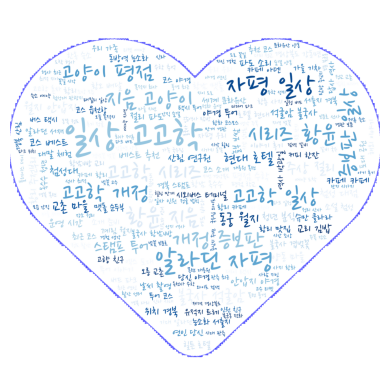

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image
# mask = np.array(Image.open('data/heart.jpg'))
import cv2
mask = cv2.imread('data/heart.jpg')
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(gj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [59]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_경주.jpg')

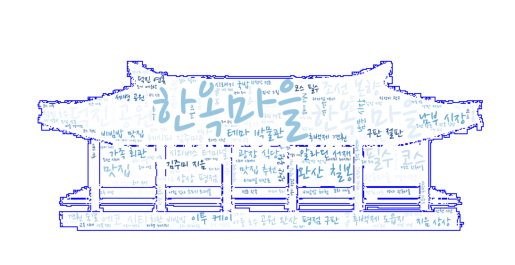

In [60]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/korea-house-black-fill.png'))
# import cv2
# mask = cv2.imread('data/korea-house-black-fill.png')
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(jj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [61]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_전주.jpg')

In [62]:
# 경주 명사들 Text plot
# 전주 명사들만 Text plot
print(gj_noun[:5])
print(jj_noun[:5])

['동궁', '월지', '첨성대', '야경', '연꽃']
['알라딘', '서재', '당일', '버스', '마음']


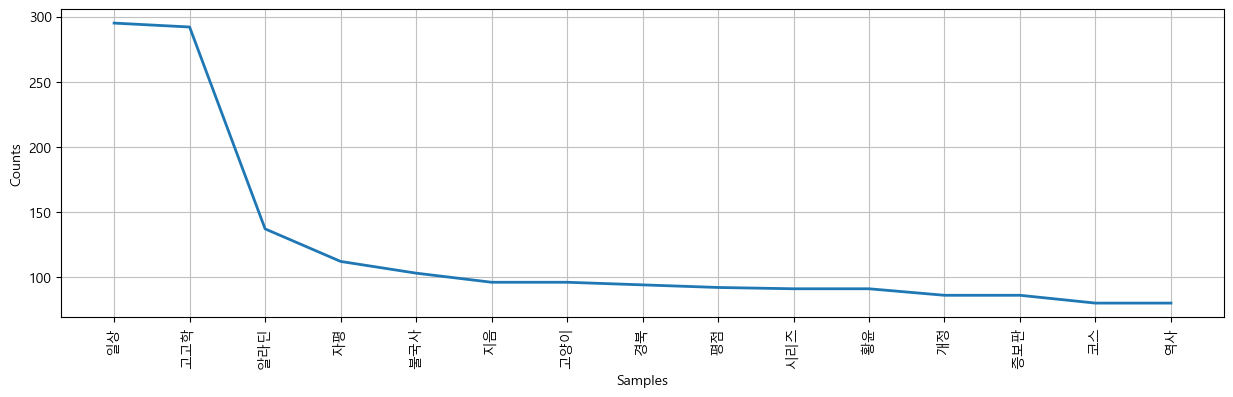

In [63]:
import nltk
import matplotlib.pyplot as plt
gj_text = nltk.Text(gj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
gj_text.plot(15)
plt.show()

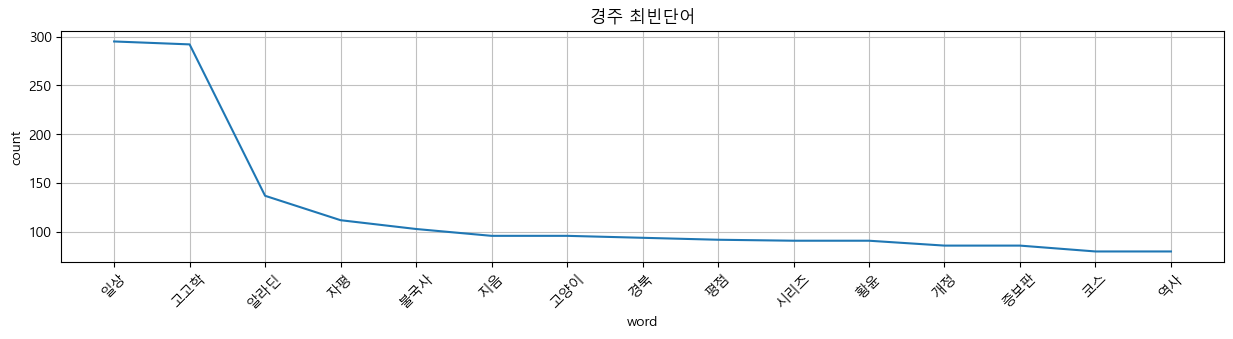

In [64]:
gj_word_counts = gj_text.vocab().most_common(15)
word   = [token for token, count in gj_word_counts]
counts = [count for token, count in gj_word_counts]
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('경주 최빈단어')
plt.grid(True, color='silver') 
plt.show()

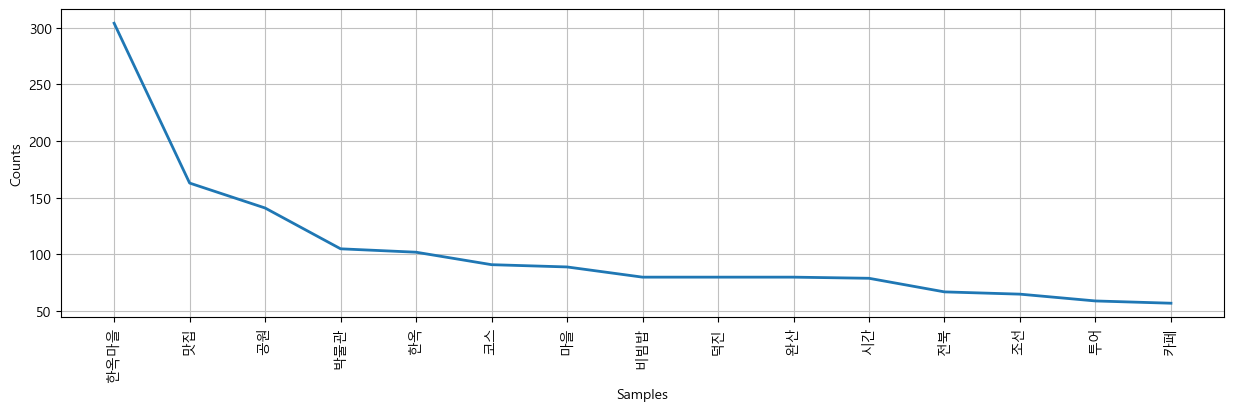

In [65]:
jj_text = nltk.Text(jj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
jj_text.plot(15)
plt.show()

In [66]:
jj_word_counts = data_text.vocab().most_common(15)
word   = [token for token, count in jj_word_counts]
counts = [count for token, count in jj_word_counts]
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('전주 최빈단어')
plt.grid(True, color='silver') 
plt.show()

NameError: name 'data_text' is not defined

## 6. 워드 임베딩
- Word2Vec

In [96]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')

In [67]:
total_text_list = df['total_text'].values.tolist()
# total_text_list = df['total_text'].to_list() 시리즈를 list로
total_text_list[-2:]

[' 전주 먹방 여행   전주 한옥마을 카페 차미라미 2022 12 20    맛집 맛집들     전주여행   전주 먹방투어 한벽집 새우탕  전주여행   전주 먹방투어 한벽집 새우탕 11월 초에 지인들과  전주 여행 을 다녀왔어요  오로지 먹방투어로 간 1박 2일  전주 여행  쉴새없이    ',
 ' 전주여행  카페이르리 메뉴판  전주 한옥마을을 돌아다니가가 수다떨겸 쉴겸 방문하였던 이르리 카페입니다  외관에 비해 내부가     전주  카페 이르리  네이버 지도  카페이르리 전북  전주 시 완산구 은행로 69  교동  http   naver me FqlI7l3r    ']

In [68]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [69]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [word for word, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(word)>1 and
                             word not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

CPU times: total: 922 ms
Wall time: 946 ms


In [70]:
print(total_noun_list[-2:])

[['전주', '먹방', '전주', '한옥', '마을', '카페', '차미', '라미', '맛집', '맛집', '전주', '전주', '먹방', '투어', '새우탕', '전주', '전주', '먹방', '투어', '새우탕', '지인', '전주', '먹방', '투어', '전주'], ['전주', '카페', '메뉴판', '전주', '한옥마을', '수다', '방문', '카페', '외관', '내부', '전주', '카페', '네이버', '지도', '카페', '전북', '전주', '완산구', '은행', '교동']]


In [71]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list,
                window=15,
                min_count=20, # 20번 이상 반복되는 단어만 거리 계산
                workers=-1,
                sg=1)

In [72]:
print(model.wv.index_to_key)
print(len(model.wv))

['전주', '경주', '한옥마을', '일상', '고고학', '맛집', '알라딘', '코스', '공원', '한옥', '마을', '시간', '투어', '자평', '박물관', '지음', '평점', '역사', '카페', '불국사', '고양이', '경북', '황윤', '시리즈', '증보판', '개정', '완산', '덕진', '비빔밥', '황리', '호텔', '야경', '첨성대', '전북', '추천', '조선', '이야기', '사진', '시장', '체험', '구경', '생각', '한국', '가을', '신라', '연꽃', '가족', '방문', '산책', '이번', '대릉원', '거리', '문화', '필수', '석굴암', '식당', '버스', '점심', '벚꽃', '본향', '서울', '터미널', '시작', '오늘', '추억', '부채', '후백제', '보문', '도착', '숙소', '시외버스', '수학', '친구', '계획', '위치', '월지', '남부', '현대', '유적지', '안압지', '칠봉', '호수', '하늘', '기대', '저녁', '주차장', '주상', '기차', '아이', '아침', '장소', '풍경', '갈비', '국내', '사람', '근처', '명소', '도시', '다음', '행복', '소리', '전화', '동궁', '광장', '날씨', '도서관', '시티', '에코', '한복', '레시피', '테마', '스탬프', '황남', '절리', '대표', '분위기', '후기', '교촌', '예전', '서재', '생태', '완주', '먹거리', '경기전', '전동성당', '남문', '혼자', '마음', '객사', '한잔', '여름', '커피', '검색', '군산', '콩나물국', '음식', '마중', '풍남문', '대한민국', '아중', '견훤', '케이', '이투', '사고', '전라북도', '이색', '전통', '만족', '국밥', '순두부', '마지막', '오후', '해외', '김밥', '느낌', '입장료', '운영', '정교', '숨결', '모습', 

In [73]:
model.wv.most_similar('전주')

[('친구', 0.2897421419620514),
 ('도읍지', 0.275379478931427),
 ('명소', 0.2295033037662506),
 ('이투', 0.22023281455039978),
 ('평점', 0.21883943676948547),
 ('한옥', 0.21617142856121063),
 ('회관', 0.20657561719417572),
 ('부채', 0.20441339910030365),
 ('비빔밥', 0.19543619453907013),
 ('오후', 0.18593086302280426)]

In [74]:
model.wv.most_similar('경주')

[('만족', 0.21469099819660187),
 ('덕진', 0.18890605866909027),
 ('황윤', 0.18855659663677216),
 ('거리', 0.18359005451202393),
 ('동궁', 0.18345923721790314),
 ('전동성당', 0.18069222569465637),
 ('명소', 0.17804880440235138),
 ('퇴근', 0.1716609001159668),
 ('도읍지', 0.1696905791759491),
 ('축제', 0.1692381650209427)]

In [75]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.


KeyboardInterrupt: Interrupted by user